In [1]:
import numpy as np
import pandas as pd
import scipy.sparse as sparse
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import fbeta_score



In [2]:
def load_data(train=True):
    if train:
        data=np.load('embeddings_1.npy')
        data=np.concatenate((data, np.load('embeddings_2.npy')), axis=0)
        labels=[]
        for file_name in ['icd_codes_1.txt', 'icd_codes_2.txt']:
            with open(file_name) as file:
                for line in file:
                    labels.append(line.strip().split(';'))
        multihot=MultiLabelBinarizer(sparse_output=True)
        labels=multihot.fit_transform(labels)
        return data, labels, multihot
    else:
        data=np.load('test_data.npy')
        return data, None, None

X, y, multihot=load_data()

In [3]:
X.shape, y.shape

((198982, 1024), (198982, 1400))

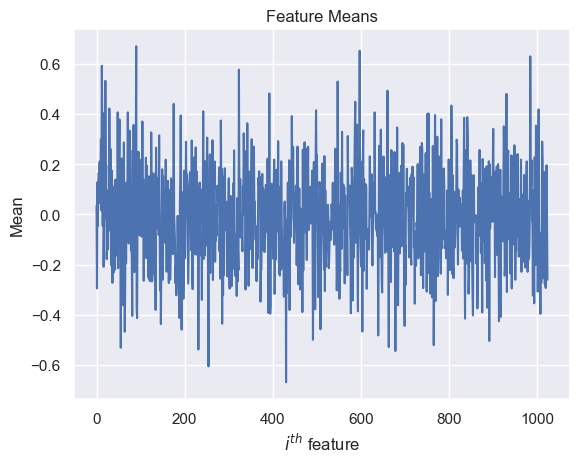

In [194]:
plt.plot(X.mean(axis=0))
plt.title('Feature Means')
plt.xlabel('$i^{th}$ feature')
plt.ylabel('Mean');

In [189]:
X.mean(axis=0).std()

np.float32(0.19805813)

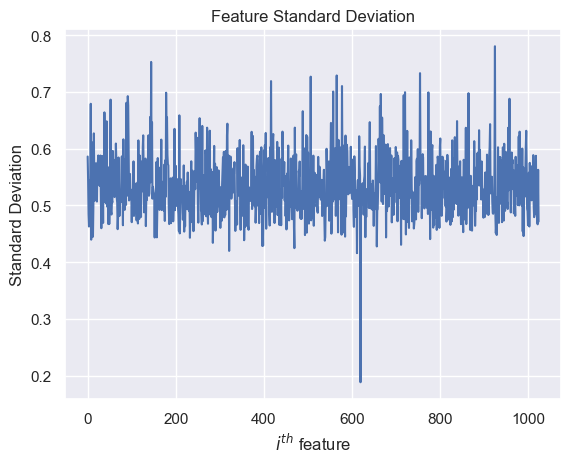

In [195]:
plt.plot(X.std(axis=0))
plt.title('Feature Standard Deviation')
plt.xlabel('$i^{th}$ feature')
plt.ylabel('Standard Deviation');

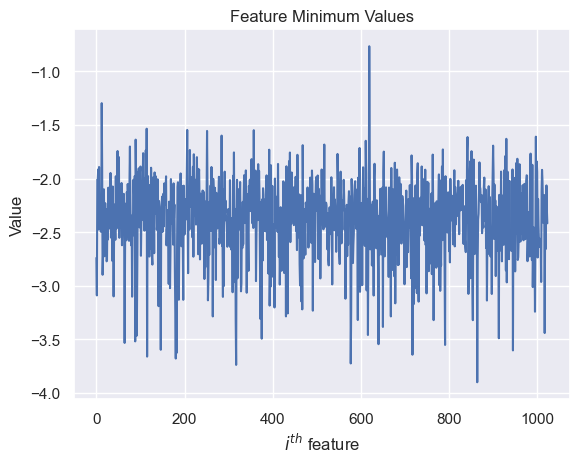

In [198]:
plt.plot(X.min(axis=0))
plt.title('Feature Minimum Values')
plt.xlabel('$i^{th}$ feature')
plt.ylabel('Value');

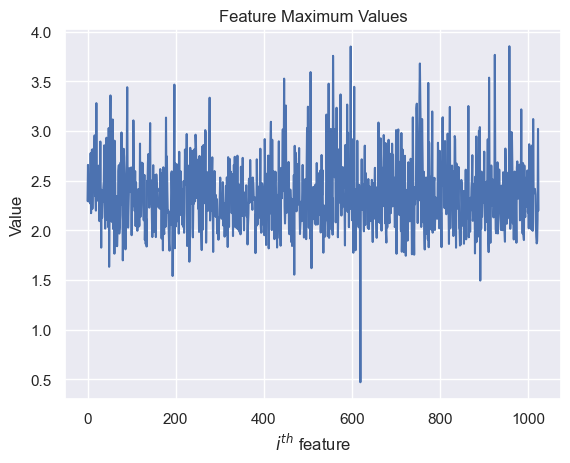

In [199]:
plt.plot(X.max(axis=0))
plt.title('Feature Maximum Values')
plt.xlabel('$i^{th}$ feature')
plt.ylabel('Value');

In [26]:
counts=np.array(y.sum(axis=0))[0]
sorted_index=counts.argsort()

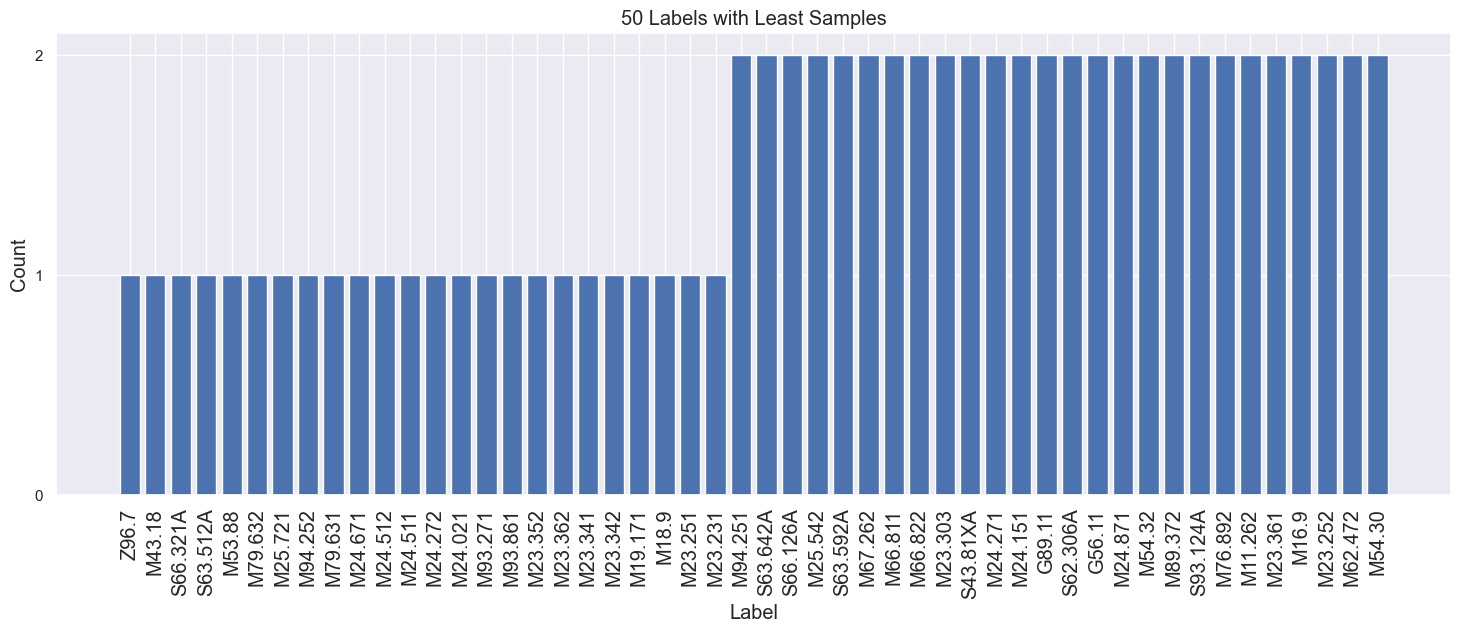

In [169]:
ax=plt.axes()
ax.bar(x=multihot.classes_[sorted_index[:50]], 
        height=counts[sorted_index[:50]])
ax.tick_params(axis='x', labelrotation=90, labelsize='large')
ax.set_title('50 Labels with Least Samples', fontsize='large')
ax.set_ylabel('Count', fontsize='large')
ax.set_xlabel('Label', fontsize='large')
ax.set_yticks([0, 1, 2 ])
plt.gcf().set_size_inches(18, 6)



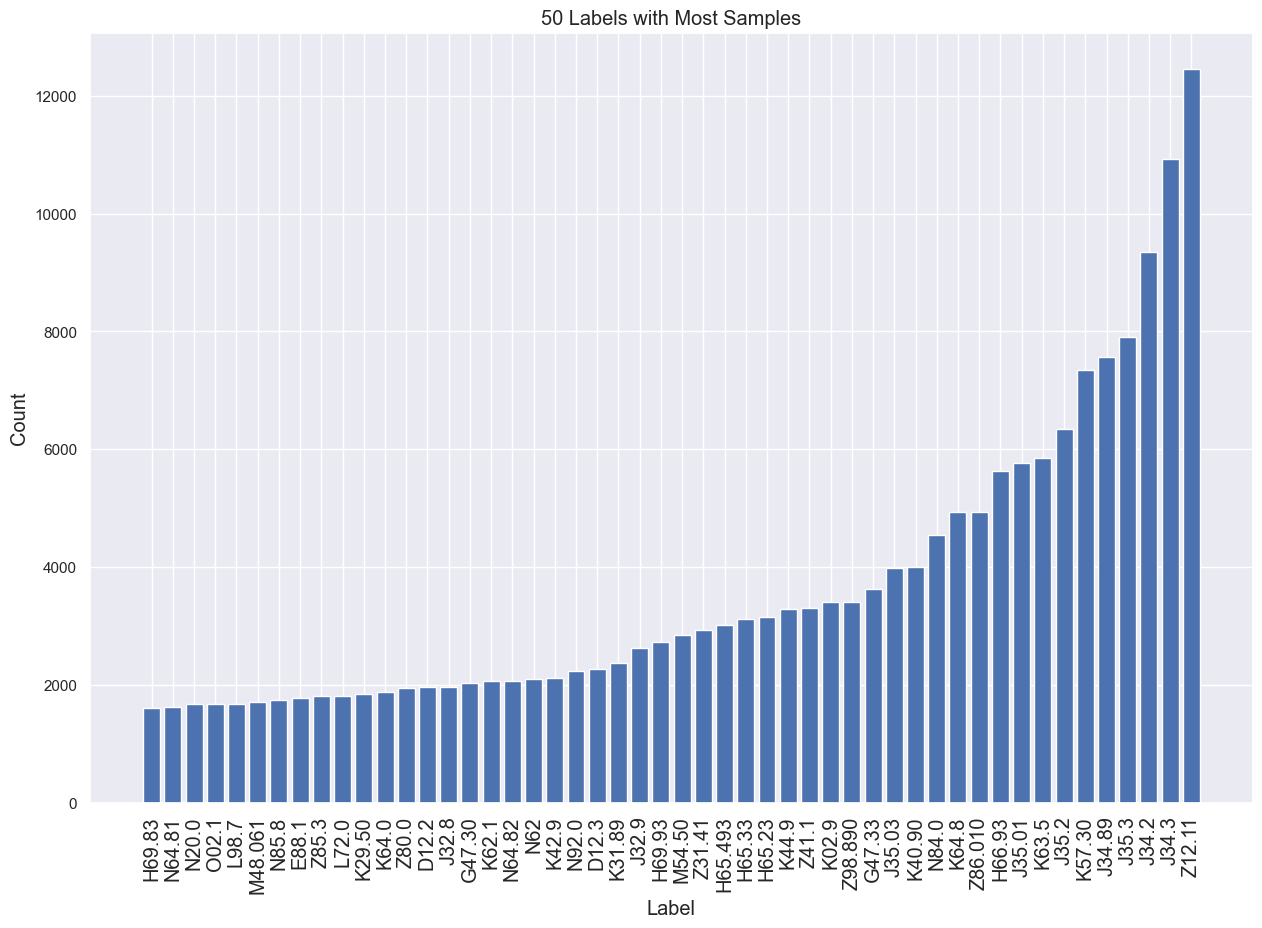

In [170]:
ax=plt.axes()
ax.bar(x=multihot.classes_[sorted_index[-50:]], 
        height=counts[sorted_index[-50:]])
ax.tick_params(axis='x', labelrotation=90, labelsize='large')
ax.set_title('50 Labels with Most Samples', fontsize='large')
ax.set_ylabel('Count', fontsize='large')
ax.set_xlabel('Label', fontsize='large')
plt.gcf().set_size_inches(15, 10)

In [52]:
coer_y=np.corrcoef(y.toarray(), rowvar=False)

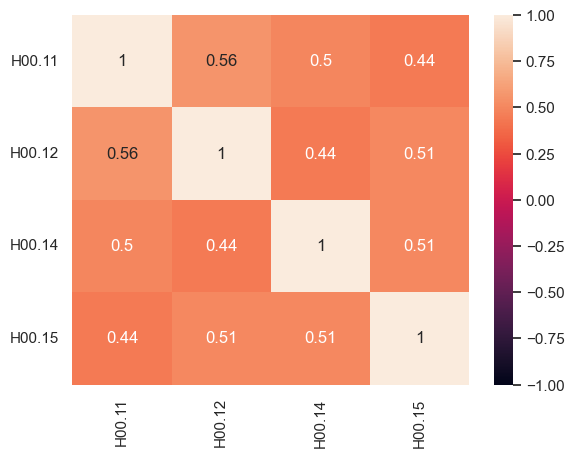

In [160]:
start, stop=187, 191
ax=sns.heatmap(coer_y[start:stop, start:stop], annot=True, vmin=-1)
ax.set_xticklabels(labels=multihot.classes_[start:stop])
ax.tick_params(axis='x', labelrotation=90)

ax.set_yticklabels(labels=multihot.classes_[start:stop])
ax.tick_params(axis='y', labelrotation=0)

## Model

In [171]:
class MultiLogReg(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator):
        self.estimators=[]
        self.estimator=estimator
        self._is_fitted=False
        self.n_outputs=0
    
    def fit(self, X, y):
        self.estimators=[]
        self.n_outputs=y.shape[1]
        for i in range(self.n_outputs):
            new_estimator=clone(self.estimator)
            try:
                new_estimator.fit(X, y[:, i].toarray().flatten())
            except ValueError:
                pass
            self.estimators.append(new_estimator)
        self._is_fitted=True
        return self
    
    def predict(self, X):
        predictions=[]
        for i in range(len(self.estimators)):
            pred=None
            try:
                pred=self.estimators[i].predict(X)
            except AttributeError:
                pred=np.zeros(X.shape[0])
            predictions.append( sparse.csr_matrix(pred) )
        
        return sparse.vstack(predictions).T

    def __sklearn_is_fitted__(self):
        return self._is_fitted
        

In [172]:
def print_performance(X_train, y_train, X_test, y_test, model):
    predictions=model.predict(X_train)
    print('Training Performance : %f'%(fbeta_score(y_train, predictions, beta=2, average='micro')*100))

    predictions=model.predict(X_test)
    print('Testing Performance : %f'%(fbeta_score(y_test, predictions, beta=2, average='micro')*100))
    

def submit(model, trans, pca=None):
    submission=load_data(False)[0]
    predictions=None
    if pca is None:
        predictions=model.predict(submission)
    else:
        predictions=model.predict(pca.transform(submission))
    label_list=trans.inverse_transform(predictions)
    ser=pd.Series( [';'.join(labels) for labels in label_list], index=range(1, len(label_list)+1))
    submission_labels=ser.reset_index().rename(columns={'index': 'id', 0: 'labels'})
    submission_labels.to_csv('sub.csv', index=False)

In [174]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.5, random_state=0)
pca=PCA(n_components=466)
X_pca_train=pca.fit_transform(X_train)
X_pca_test=pca.transform(X_test)

In [175]:
pca.explained_variance_ratio_.sum()

np.float32(0.9494031)

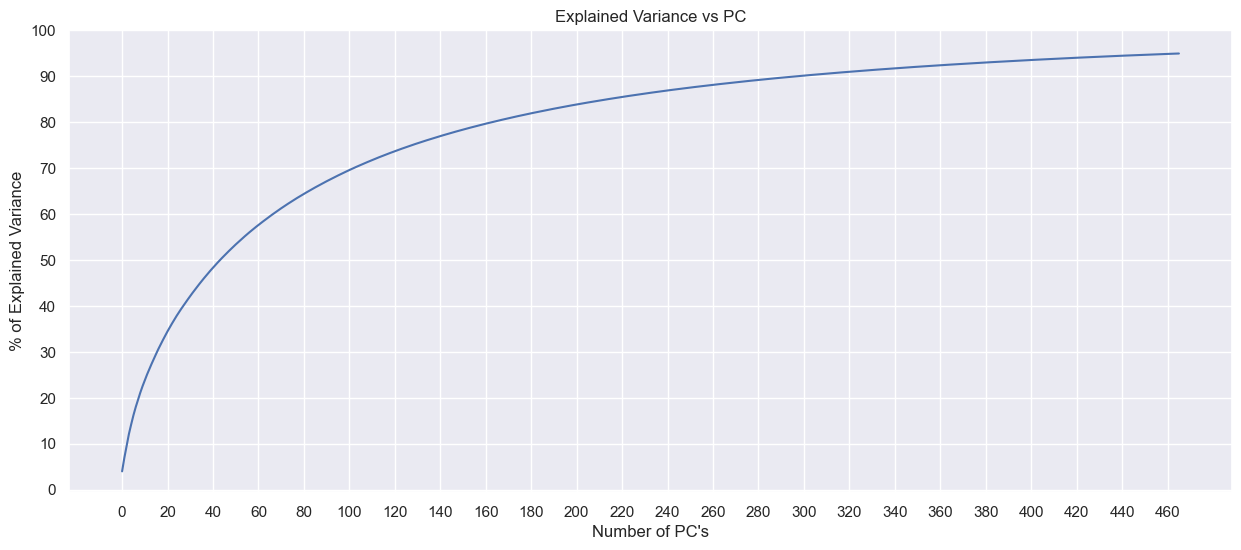

In [186]:
plt.plot(pca.explained_variance_ratio_.cumsum()*100)
ax=plt.gca()
ax.set_title('Explained Variance vs PC')
ax.set_xlabel("Number of PC's")
ax.set_ylabel('% of Explained Variance')
ax.set_yticks(np.arange(stop=110, step=10))
ax.set_xticks(np.arange(stop=480, step=20));
plt.gcf().set_size_inches(15, 6)

In [9]:
clsf=MultiLogReg(LogisticRegression())
clsf.fit(X_pca_train, y_train)

MultiLogReg(estimator=LogisticRegression())

In [11]:
print_performance(X_pca_train, y_train, X_pca_test, y_test, clsf)

Training Performance : 87.394539
Testing Performance : 79.558043


## whole training

In [16]:
pca=PCA(n_components=466)
X_pca=pca.fit_transform(X)

In [17]:
pca.explained_variance_ratio_.sum()

np.float32(0.9492257)

In [18]:
clsf=MultiLogReg(LogisticRegression())
clsf.fit(X_pca, y)

MultiLogReg(estimator=LogisticRegression())

In [19]:
print_performance(X_pca, y, X_pca, y, clsf)

Training Performance : 84.307225
Testing Performance : 84.307225


In [20]:
submit(clsf, multihot, pca)